# 06 — Financial application
Apply the same development specification to the four-asset return panel: RNN, BRNN, CA-RNN, and CA-BRNN. CA-RNN and CA-BRNN include projected-PIT and temporal PIT-moment penalties. Hyperparameters are fixed before viewing this notebook's test metrics.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from innovcal.ca_rnn import CARNNConfig, TrainingConfig
from innovcal.data import clean_adjusted_prices, download_adjusted_prices
from innovcal.experiments import run_four_model_comparison
OUT = ROOT / 'results' / 'financial'; OUT.mkdir(parents=True, exist_ok=True)
PROCESSED = ROOT / 'data' / 'processed'; PROCESSED.mkdir(parents=True, exist_ok=True)

In [2]:
returns_path = PROCESSED / 'financial_returns.csv'
if returns_path.exists():
    returns = pd.read_csv(returns_path, index_col=0, parse_dates=True)
else:
    raw = download_adjusted_prices(['AAPL', 'JPM', 'XOM', 'WMT'], '2007-01-01', '2026-01-01')
    prices, returns = clean_adjusted_prices(raw)
    prices.to_csv(PROCESSED / 'market_prices.csv')
    returns.to_csv(returns_path)
returns = returns[['AAPL', 'JPM', 'XOM', 'WMT']].dropna().sort_index()
assert returns.index.is_monotonic_increasing and not returns.index.has_duplicates
assert returns.notna().all().all()
display(returns.describe().T)

,count,mean,std,min,25%,50%,75%,max
AAPL,4779.0,0.000980,0.019793,-0.197470,-0.007833,0.001094,0.011151,0.142617
JPM,4779.0,0.000499,0.023427,-0.232278,-0.008328,0.000540,0.009582,0.223917
XOM,4779.0,0.000240,0.016958,-0.150271,-0.007653,0.000246,0.008483,0.158631
WMT,4779.0,0.000490,0.013044,-0.120765,-0.005550,0.000659,0.006635,0.110723


In [3]:
n = len(returns)
train_end = int(0.60 * n)
validation_end = train_end + int(0.20 * n)
split_summary = pd.DataFrame({
    'partition': ['train', 'validation', 'test'],
    'start': [returns.index[0], returns.index[train_end], returns.index[validation_end]],
    'end': [returns.index[train_end - 1], returns.index[validation_end - 1], returns.index[-1]],
    'observations': [train_end, validation_end - train_end, n - validation_end],
})
display(split_summary)
split_summary.to_csv(OUT / 'financial_split.csv', index=False)

,partition,start,end,observations
0,train,2007-01-04,2018-05-23,2867
1,validation,2018-05-24,2022-03-09,955
2,test,2022-03-10,2025-12-31,957


In [4]:
training = TrainingConfig(
    epochs=200,
    batch_size=64,
    patience=25,
    bayesian_samples=2,
    seed=606,
    selection_metric='nll',
)
result = run_four_model_comparison(
    returns.to_numpy(),
    model_config=CARNNConfig(input_dim=4, hidden_dim=32),
    training_config=training,
    lambda_cal=100.0,
    lambda_seq=2000.0,
    n_forecast_samples=500,
)
metrics = result.metrics.sort_values('pit_calibration_error').reset_index(drop=True)
display(metrics)
metrics.to_csv(OUT / 'financial_metrics.csv', index=False)
for name, history in result.histories.items():
    safe_name = name.lower().replace(' ', '_')
    history.to_csv(OUT / f'{safe_name}_history.csv', index=False)

,model,best_epoch,nll,rmse,energy_score,coverage,interval_width,interval_score,pit_calibration_error,pit_mean_absolute_autocorrelation,pit_mean_ks,coordinate_pit_calibration_error,coordinate_pit_mean_absolute_autocorrelation,coordinate_pit_mean_ks
0,CA-BRNN,29,5.260679,0.947966,1.156594,0.890021,2.683661,4.089661,0.001104,0.033922,0.055006,0.001507,0.031472,0.067429
1,CA-RNN,45,5.251510,0.946669,1.150626,0.884013,2.621694,4.066520,0.001149,0.037049,0.054576,0.001492,0.036078,0.065357
2,BRNN,26,5.257915,0.942525,1.150925,0.891850,2.642791,4.065377,0.001267,0.030763,0.058904,0.001721,0.029852,0.071406
3,RNN,40,5.270610,0.939368,1.143727,0.876437,2.528633,4.072943,0.001344,0.032110,0.058604,0.001771,0.030376,0.070270


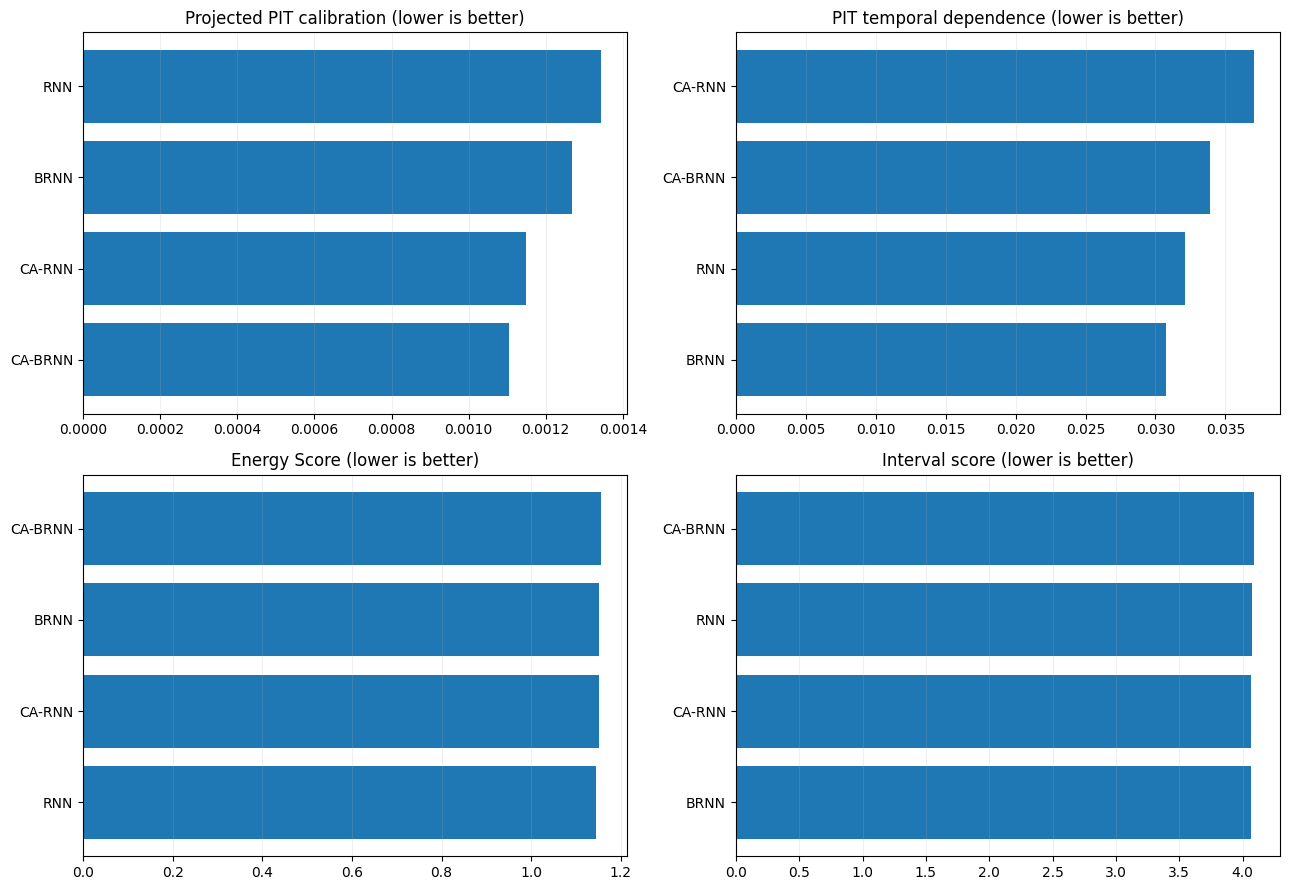

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
plot_metrics = [
    ('pit_calibration_error', 'Projected PIT calibration'),
    ('pit_mean_absolute_autocorrelation', 'PIT temporal dependence'),
    ('energy_score', 'Energy Score'),
    ('interval_score', 'Interval score'),
]
for axis, (metric, title) in zip(axes.flat, plot_metrics):
    ordered = metrics.sort_values(metric)
    axis.barh(ordered.model, ordered[metric])
    axis.set_title(title + ' (lower is better)')
    axis.grid(axis='x', alpha=0.2)
plt.tight_layout()
fig.savefig(OUT / 'financial_comparison.png', dpi=180, bbox_inches='tight')

In [6]:
paired = []
for candidate, comparator in [
    ('CA-RNN', 'RNN'),
    ('CA-BRNN', 'BRNN'),
]:
    candidate_row = metrics.set_index('model').loc[candidate]
    comparator_row = metrics.set_index('model').loc[comparator]
    paired.append({
        'comparison': f'{candidate} minus {comparator}',
        **{metric: candidate_row[metric] - comparator_row[metric] for metric in [
            'nll', 'energy_score', 'interval_score',
            'pit_calibration_error', 'pit_mean_absolute_autocorrelation'
]},
    })
paired = pd.DataFrame(paired)
display(paired)
paired.to_csv(OUT / 'financial_paired_differences.csv', index=False)

,comparison,nll,energy_score,interval_score,pit_calibration_error,pit_mean_absolute_autocorrelation
0,CA-RNN minus RNN,-0.019100,0.006899,-0.006423,-0.000195,0.004939
1,CA-BRNN minus BRNN,0.002764,0.005669,0.024284,-0.000163,0.003160


In [7]:
# Export matched origin-level forecasts for dependence-aware inference in notebook 07.
import numpy as np
if hasattr(result, 'forecast_samples'):
    export_target = result.target
    export_samples = result.forecast_samples
else:
    # Compatibility with a result fitted before forecast retention was added.
    import torch
    from torch.utils.data import DataLoader
    from innovcal.ca_rnn import sample_forecasts
    from innovcal.data import chronological_split
    from innovcal.data.windows import partition_window_datasets
    split = chronological_split(returns.to_numpy())
    _, _, test_dataset = partition_window_datasets(split, result.standardizer, history=20)
    export_context, export_target_tensor = next(iter(DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)))
    export_target = export_target_tensor.numpy()
    export_samples = {}
    for name, model in result.models.items():
        torch.manual_seed(training.seed + 20_000)
        export_samples[name] = sample_forecasts(model, export_context, 500).cpu().numpy()
forecast_payload = {
    'target': export_target,
    'projections': result.projections.cpu().numpy(),
}
manifest_rows = []
for index, (name, samples) in enumerate(export_samples.items()):
    key = f'samples_{index}'
    forecast_payload[key] = samples
    manifest_rows.append({'model': name, 'array_key': key})
np.savez_compressed(OUT / 'financial_forecasts.npz', **forecast_payload)
pd.DataFrame(manifest_rows).to_csv(OUT / 'financial_forecast_manifest.csv', index=False)
print(f"Saved {len(manifest_rows)} matched forecast arrays for {len(export_target)} test origins.")

Saved 4 matched forecast arrays for 957 test origins.


## Interpretation rules
This is one chronological market split, not a repeated experiment. Negative paired differences are favorable for the reported loss metrics, but no difference is statistically established without origin-level paired uncertainty. Do not retune the method from this test table. The next empirical stage must add rolling or blocked uncertainty estimates and evaluation across fresh historical splits.